# Laboratório 6 – Limiarização


*   Leonardo Garcia dos Santos 11202230441
*   Ronaldo Avila de Arruda Junior 11202231908

27 de Março de 2026


## Introdução

Neste laboratório, o objetivo principal é explorar as técnicas de limiarização (thresholding) em imagens digitais. A limiarização é uma operação bem importante de segmentação, que nos permite separar os objetos de interesse do fundo da imagem com base na intensidade dos pixels. Ao longo da prática, aplicamos e comparamos a limiarização manual, onde o valor do limiar é escolhido meio que por tentativa e erro, e a limiarização adaptativa de Otsu, que é um método automático que calcula o limiar ideal baseando-se no histograma da imagem. Também aproveitamos para aplicar essas técnicas nas imagens do nosso projeto final para ver como elas se comportam dentro do contexto da nossa aplicação.

### 3

#### **(3.a). Elabore um programa para realizar as operações de limiarização manual, e limiarização adaptativa de Otsu. Sobre as imagens individuais de cada integrante da equipe bem como nos respectivos avatares, e apresente os resultados. Elabore uma análise detalhada de cada imagem, experimentado diversos valores do limiar e compare com o limiar de Otsu, quanto ao resultado visual (aparência, representação, etc) da imagens binárias obtidas.**

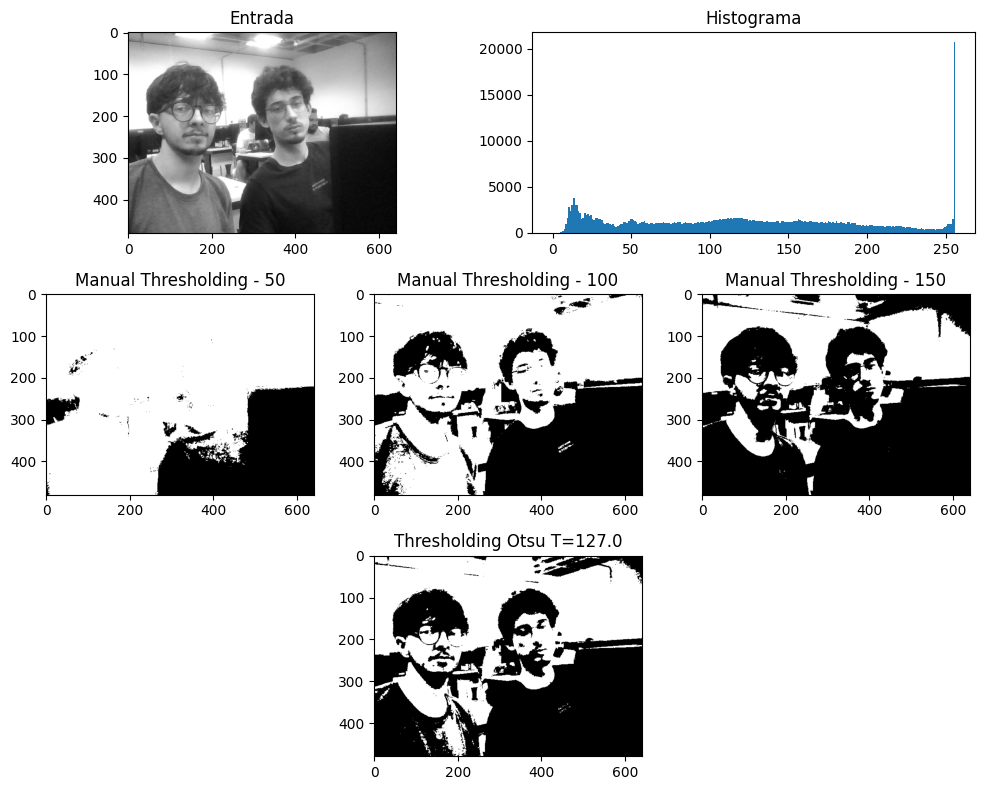

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.imread('foto1.png')
f = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

T,c = cv2.threshold(f,0,255,cv2.THRESH_OTSU)

fig = plt.figure(figsize=(10, 8))

# Define a 3x6 grid
grid_shape = (3, 6)

# --- First Row: 2 plots ---
# (0,0) is the starting coordinate, colspan is how wide it is
ax1 = plt.subplot2grid(grid_shape, (0, 0), colspan=3)
ax1.set_title("Row 1 - Plot 1")
ax1.imshow(f,"gray"),plt.title('Entrada')

ax2 = plt.subplot2grid(grid_shape, (0, 3), colspan=3)
ax2.set_title("Row 1 - Plot 2")
ax2.hist(f.ravel(), bins=256, range=[0,256]),plt.title('Histograma')

# --- Second Row: 3 plots ---
ax3 = plt.subplot2grid(grid_shape, (1, 0), colspan=2)
ax3.set_title("Row 2 - Plot 1")
ax3.imshow(f > 50, "gray"),plt.title('Manual Thresholding - 50')

ax4 = plt.subplot2grid(grid_shape, (1, 2), colspan=2)
ax4.set_title("Row 2 - Plot 2")
ax4.imshow(f > 100, "gray"),plt.title('Manual Thresholding - 100')

ax5 = plt.subplot2grid(grid_shape, (1, 4), colspan=2)
ax5.set_title("Row 2 - Plot 3")
ax5.imshow(f > 150, "gray"),plt.title('Manual Thresholding - 150')

# --- Third Row: 1 plot ---
ax6 = plt.subplot2grid(grid_shape, (2, 0), colspan=6)
ax6.set_title("Row 3 - Big Plot")
ax6.imshow(c,"gray"),plt.title('Thresholding Otsu T='+str(T))

plt.tight_layout()
plt.show()

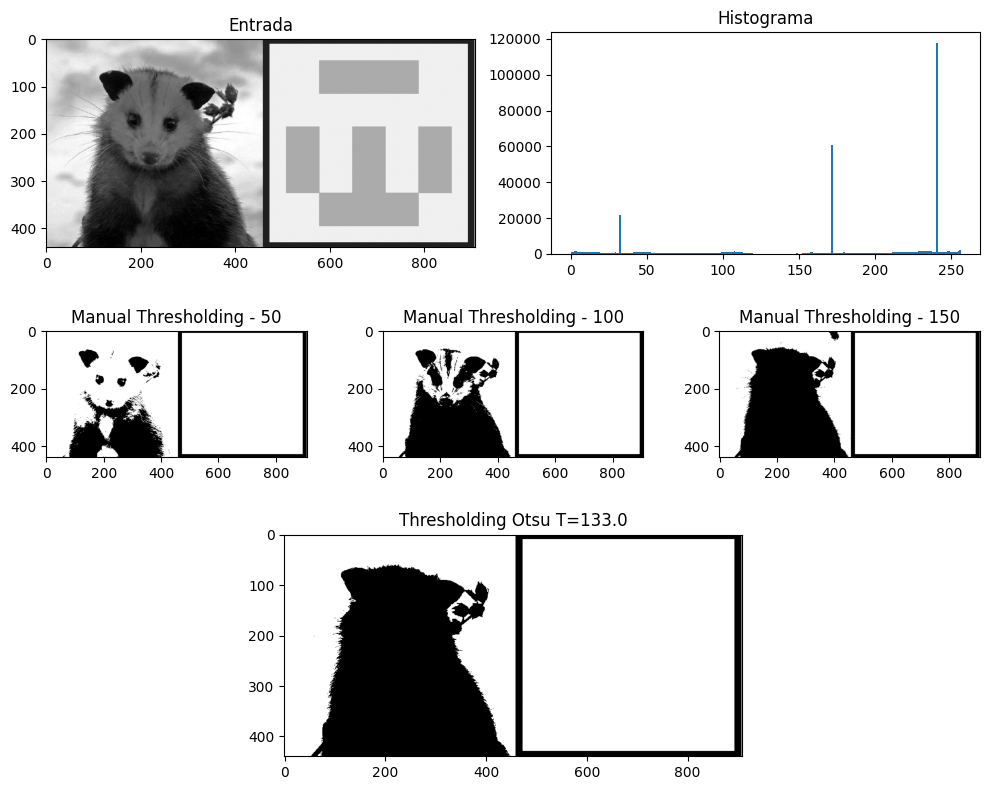

In [ ]:
img = cv2.imread('avatar.png')
f = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

T,c = cv2.threshold(f,0,255,cv2.THRESH_OTSU)

fig = plt.figure(figsize=(10, 8))

# Define a 3x6 grid
grid_shape = (3, 6)

# --- First Row: 2 plots ---
# (0,0) is the starting coordinate, colspan is how wide it is
ax1 = plt.subplot2grid(grid_shape, (0, 0), colspan=3)
ax1.set_title("Row 1 - Plot 1")
ax1.imshow(f,"gray"),plt.title('Entrada')

ax2 = plt.subplot2grid(grid_shape, (0, 3), colspan=3)
ax2.set_title("Row 1 - Plot 2")
ax2.hist(f.ravel(), bins=256, range=[0,256]),plt.title('Histograma')

# --- Second Row: 3 plots ---
ax3 = plt.subplot2grid(grid_shape, (1, 0), colspan=2)
ax3.set_title("Row 2 - Plot 1")
ax3.imshow(f > 50, "gray"),plt.title('Manual Thresholding - 50')

ax4 = plt.subplot2grid(grid_shape, (1, 2), colspan=2)
ax4.set_title("Row 2 - Plot 2")
ax4.imshow(f > 100, "gray"),plt.title('Manual Thresholding - 100')

ax5 = plt.subplot2grid(grid_shape, (1, 4), colspan=2)
ax5.set_title("Row 2 - Plot 3")
ax5.imshow(f > 150, "gray"),plt.title('Manual Thresholding - 150')

# --- Third Row: 1 plot ---
ax6 = plt.subplot2grid(grid_shape, (2, 0), colspan=6)
ax6.set_title("Row 3 - Big Plot")
ax6.imshow(c,"gray"),plt.title('Thresholding Otsu T='+str(T))

plt.tight_layout()
plt.show()

O limiar manual permite um controle maior sobre a segmentação final, porém, o caso da imagem dos avatares, o Otsu foi bem preciso para segmentar o gambá. Para a imagem contendo pessoas, nem o Otsu conseguiu segmentar automaticamente. Nesse caso, é claro a necessidade de controlar o valor do limiar. No entanto, qualquer mudança de ambiente, iluminação, pode afetar a qualidade da segmetação.

#### **(3.b)Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as operações de limiarização, mostrando na tela em tempo real lado-a-lado a imagem original e a imagem limiarizada, permitindo ao operador escolher – via teclado – a limiarização manual ou a limiarização dinâmica de Otsu. Grave um video demonstrativo com os integrantes da equipe utilizando este programa com a webcam. Elabore uma análise detalhada e explique os artefatos ocorridos.**

In [ ]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)

mode = 0 # 0: Manual, 1: Otsu
limiar = 50
print("Controles: '0'-Manual | '1'-Otsu | '>' '<' Varia limiar manual | 'q'-Sair")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if limiar < 0:
        limiar = 0
    elif limiar > 255:
        limiar = 255
    # 1. Pré-processamento: BGR para RGB e normalização em float32
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_RGBA2GRAY)
    display_frame = frame_gray.copy()

    # 2. Processamento
    if mode == 0:
        display_frame = (frame_gray > limiar).astype(np.uint8) * 255

    if mode == 1:
        T,c = cv2.threshold(frame_gray,0,255,cv2.THRESH_OTSU)
        display_frame = c

    exibicao_lado_a_lado = np.hstack((frame_gray, display_frame))

    modes_text = ["Manual", "Otsu"]
    cv2.putText(exibicao_lado_a_lado, f"Modo: {modes_text[mode]}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    if mode == 0:
        cv2.putText(exibicao_lado_a_lado, f"Limiar: {limiar}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    if mode == 1:
        cv2.putText(exibicao_lado_a_lado, f"T: {T}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    cv2.imshow('Processamento em Tempo Real', exibicao_lado_a_lado)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('0'):
        mode = 0
    elif key == ord('1'):
        mode = 1
    elif key == ord('>'):
        limiar += 1
    elif key == ord('<'):
        limiar -= 1

cap.release()
cv2.destroyAllWindows()

Controles: '0'-Manual | '1'-Otsu | '>' '<' Varia limiar manual | 'q'-Sair


In [1]:
from IPython.display import Video

Video("https://github.com/Ragnavald/PDI-Processamento-Digital-de-Imagem/raw/refs/heads/main/Lab6/Grava%C3%A7%C3%A3o%20de%20tela%20de%202026-03-27%2020-34-08.webm", width=500.0)

O programa desenvolvido permite escolher entre o metodo manual e o Otsu, também permitindo alterar o valor do limiar manual. É possivel ver que, no caso de um video, o limiar manual pode facilmente apresentar artefatos devido as mudanças constantes na imagem. De forma semelhante, é possível ver como o Otsu atualiza constantemente o valor do limiar usado.

### 4

#### **(4.a) Elabore um programa para realizar as operações de limiarização nas imagens do seu trabalho final, explicando o objetivo deste procedimento dentro do contexto da aplicação.**

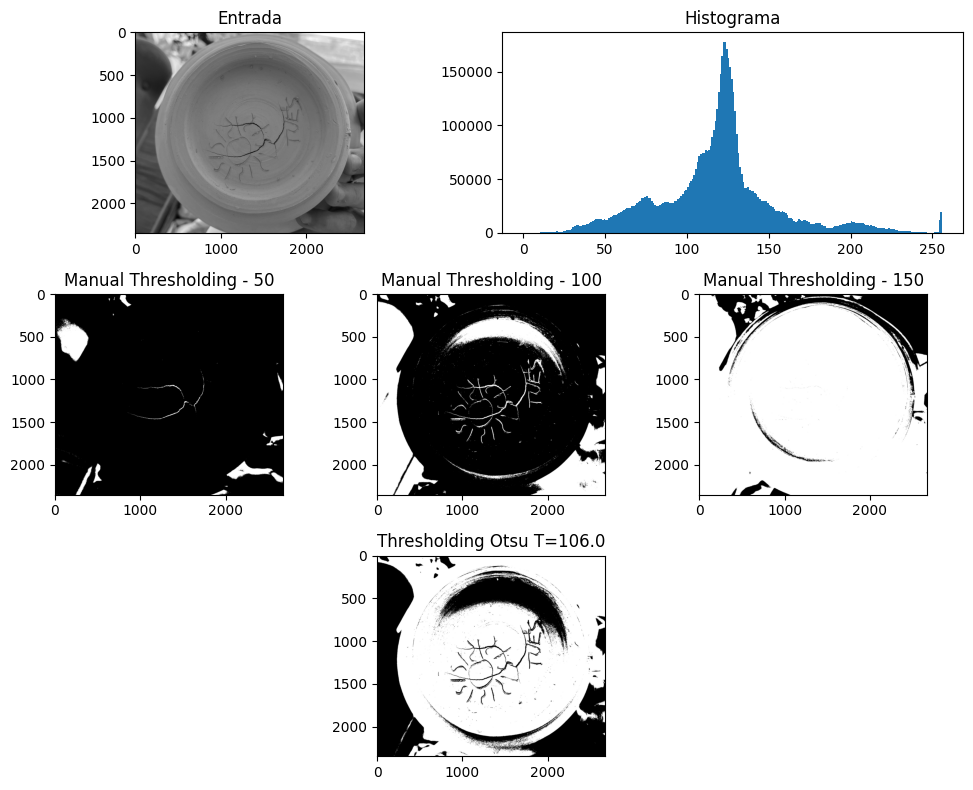

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.imread('01.jpg')
f = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

T,c = cv2.threshold(f,0,255,cv2.THRESH_OTSU)

fig = plt.figure(figsize=(10, 8))

# Define a 3x6 grid
grid_shape = (3, 6)

# --- First Row: 2 plots ---
# (0,0) is the starting coordinate, colspan is how wide it is
ax1 = plt.subplot2grid(grid_shape, (0, 0), colspan=3)
ax1.set_title("Row 1 - Plot 1")
ax1.imshow(f,"gray"),plt.title('Entrada')

ax2 = plt.subplot2grid(grid_shape, (0, 3), colspan=3)
ax2.set_title("Row 1 - Plot 2")
ax2.hist(f.ravel(), bins=256, range=[0,256]),plt.title('Histograma')

# --- Second Row: 3 plots ---
ax3 = plt.subplot2grid(grid_shape, (1, 0), colspan=2)
ax3.set_title("Row 2 - Plot 1")
ax3.imshow(f < 50, "gray"),plt.title('Manual Thresholding - 50')

ax4 = plt.subplot2grid(grid_shape, (1, 2), colspan=2)
ax4.set_title("Row 2 - Plot 2")
ax4.imshow(f < 100, "gray"),plt.title('Manual Thresholding - 100')

ax5 = plt.subplot2grid(grid_shape, (1, 4), colspan=2)
ax5.set_title("Row 2 - Plot 3")
ax5.imshow(f < 150, "gray"),plt.title('Manual Thresholding - 150')

# --- Third Row: 1 plot ---
ax6 = plt.subplot2grid(grid_shape, (2, 0), colspan=6)
ax6.set_title("Row 3 - Big Plot")
ax6.imshow(c,"gray"),plt.title('Thresholding Otsu T='+str(T))

plt.tight_layout()
plt.show()

No contexto do projeto, detectar rachaduras em vasos, é possível usar a limiarização manual para detectar uma rachadura com base em ela ser radicalmente escura em comparação com o restante do objeto. O metodo Otsu e sua maior vantagem de ser automatico, poderia ser util em caso de um ambiente descontrolado, porém o ambiente controlado de uma linha de produção, onde o vaso está presente à frente de um fundo uniforme, e iluminação uniforme, permite que um limiar manual bem definido seja eficiente consistentemente

### 5

#### **(5.a). No contexto da limiarização de imagens, o notebook apresenta a inspeção visual do histograma e os métodos automáticos como formas de escolher um limiar. Explique a diferença fundamental entre essas duas abordagens para a seleção do limiar T. Quais são as principais vantagens e desvantagens de cada método, considerando a precisão, a subjetividade e a aplicabilidade a diferentes tipos de imagens?**

Na escolha manual, é possivel tentar definir os segmnentos de interesse, e assim se tem mais controle sobre o que é segmentado. Porém, o uso do limiar fixo torna o efeito inconscistente ao longo prazo, visto que imagens diferentes podem ter mudançças de iluminação que altera os objetos segmentados e pode gerar artefatos. No metodo automatico do Otsu, perde-se o controle fino sobre o procedimento, porém a escolha automatica do limiar permite que ele seja usado em diversas imagens diferentes com resultados semelhantes, inclusive em videos

#### **(5.b). Considerando a “img2” e seu histograma, discuta o impacto da escolha de diferentes limiares. Explique por que um limiar muito baixo (“T=50”) ou muito alto (“T=125”) pode resultar em uma segmentação insatisfatória. Com base no histogramada “img2” , sugira um valor de limiar que você consideraria mais adequado para separar os objetos do fundo e justifique sua escolha.**

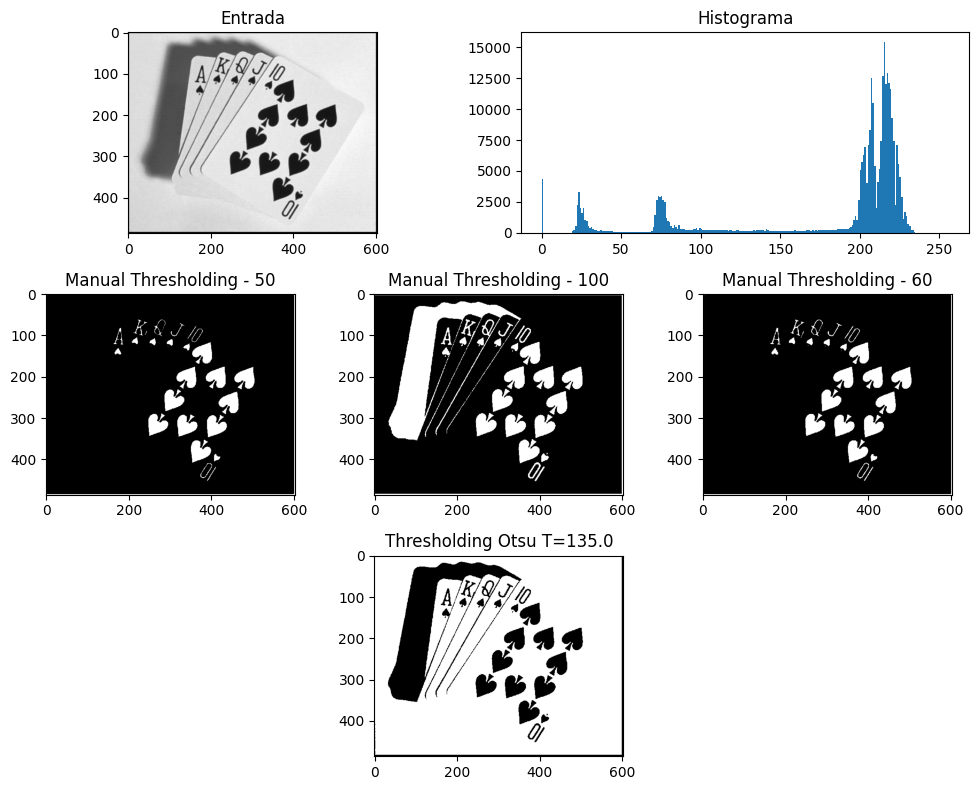

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.imread('aula04fig02.png')
f = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

T,c = cv2.threshold(f,0,255,cv2.THRESH_OTSU)

fig = plt.figure(figsize=(10, 8))

# Define a 3x6 grid
grid_shape = (3, 6)

# --- First Row: 2 plots ---
# (0,0) is the starting coordinate, colspan is how wide it is
ax1 = plt.subplot2grid(grid_shape, (0, 0), colspan=3)
ax1.set_title("Row 1 - Plot 1")
ax1.imshow(f,"gray"),plt.title('Entrada')

ax2 = plt.subplot2grid(grid_shape, (0, 3), colspan=3)
ax2.set_title("Row 1 - Plot 2")
ax2.hist(f.ravel(), bins=256, range=[0,256]),plt.title('Histograma')

# --- Second Row: 3 plots ---
ax3 = plt.subplot2grid(grid_shape, (1, 0), colspan=2)
ax3.set_title("Row 2 - Plot 1")
ax3.imshow(f < 50, "gray"),plt.title('Manual Thresholding - 50')

ax4 = plt.subplot2grid(grid_shape, (1, 2), colspan=2)
ax4.set_title("Row 2 - Plot 2")
ax4.imshow(f < 125, "gray"),plt.title('Manual Thresholding - 100')

ax5 = plt.subplot2grid(grid_shape, (1, 4), colspan=2)
ax5.set_title("Row 2 - Plot 3")
ax5.imshow(f < 60, "gray"),plt.title('Manual Thresholding - 60')

# --- Third Row: 1 plot ---
ax6 = plt.subplot2grid(grid_shape, (2, 0), colspan=6)
ax6.set_title("Row 3 - Big Plot")
ax6.imshow(c,"gray"),plt.title('Thresholding Otsu T='+str(T))

plt.tight_layout()
plt.show()

Simplesmente, o limiar muito alto pega muito, com o exemplo da sombra das cartas sendo capturada pelo limiar, tendo falso positivos. O limiar baixo, em contraparte, falha em pegar o que se espera pegar, exemplificado pela fraca definição das letras e numeros segmentados das cartas.

Na escolha manual, o limiar de 60 parece conseguir dar melhor definição para os elementos segmentados, enquanto evita artefatos.

#### **(5.c). Com base na imagem “rice.png” (Exemplo 5) e nos resultados obtidos com o método de Otsu, qual a principal vantagem de utilizar um método automático como o de Otsu em comparação com a "tentativa e erro" para a segmentação de grãos de arroz neste tipo de imagem?**

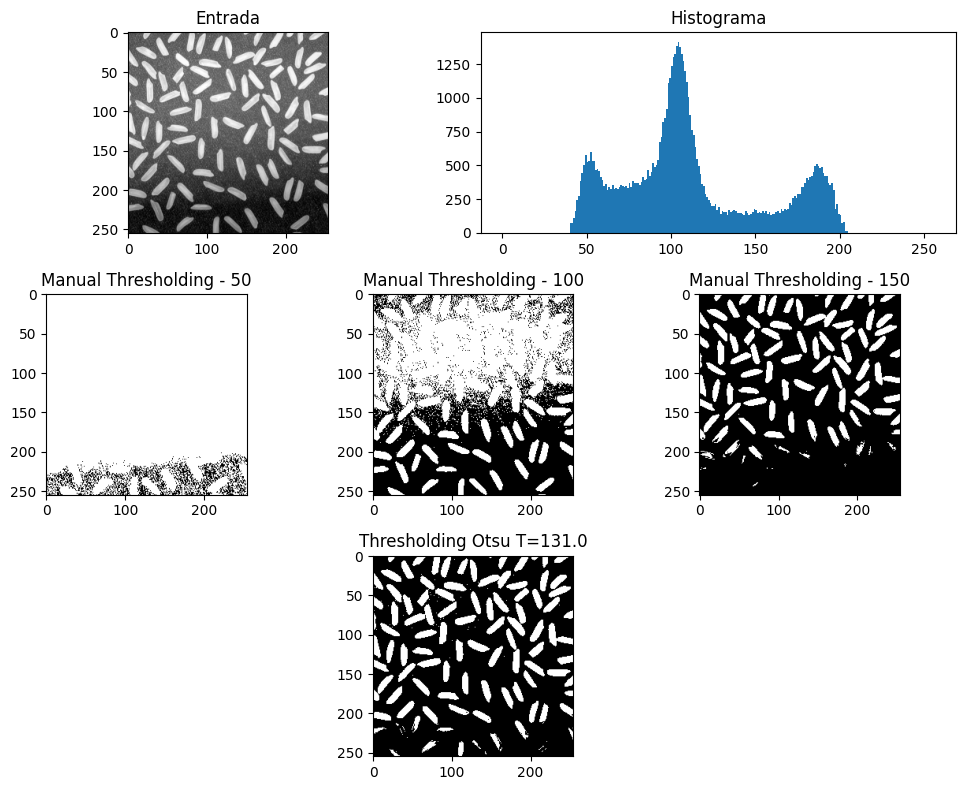

In [14]:
img = cv2.imread('rice.png')
f = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)
f = f[30:285,85:340]

T,c = cv2.threshold(f,0,255,cv2.THRESH_OTSU)

fig = plt.figure(figsize=(10, 8))

# Define a 3x6 grid
grid_shape = (3, 6)

# --- First Row: 2 plots ---
# (0,0) is the starting coordinate, colspan is how wide it is
ax1 = plt.subplot2grid(grid_shape, (0, 0), colspan=3)
ax1.set_title("Row 1 - Plot 1")
ax1.imshow(f,"gray"),plt.title('Entrada')

ax2 = plt.subplot2grid(grid_shape, (0, 3), colspan=3)
ax2.set_title("Row 1 - Plot 2")
ax2.hist(f.ravel(), bins=256, range=[0,256]),plt.title('Histograma')

# --- Second Row: 3 plots ---
ax3 = plt.subplot2grid(grid_shape, (1, 0), colspan=2)
ax3.set_title("Row 2 - Plot 1")
ax3.imshow(f > 50, "gray"),plt.title('Manual Thresholding - 50')

ax4 = plt.subplot2grid(grid_shape, (1, 2), colspan=2)
ax4.set_title("Row 2 - Plot 2")
ax4.imshow(f > 100, "gray"),plt.title('Manual Thresholding - 100')

ax5 = plt.subplot2grid(grid_shape, (1, 4), colspan=2)
ax5.set_title("Row 2 - Plot 3")
ax5.imshow(f > 150, "gray"),plt.title('Manual Thresholding - 150')

# --- Third Row: 1 plot ---
ax6 = plt.subplot2grid(grid_shape, (2, 0), colspan=6)
ax6.set_title("Row 3 - Big Plot")
ax6.imshow(c,"gray"),plt.title('Thresholding Otsu T='+str(T))

plt.tight_layout()
plt.show()

A vantagem óbvia é a praticidade, visto que seria necessário esforço e tempo para conseguir acertar um limiar suficientemente adequado de forma manual. Porém, também é claro que, em um contexto onde a imagem pode mudar, junto com as condições de iluminação e do ambiente (como em um vídeo), o método automático consegue manter a consistência do resultado, evitando ter que atualizar os limiares manualmente.

## Conclusões

Com as práticas realizadas neste laboratório, deu para ver na prática como a limiarização ajuda na segmentação de imagens. Ao comparar a abordagem manual com o método de Otsu, a gente percebe que o método manual até gera bons resultados quando ajustado com bastante cuidado, mas ele exige tempo e não lida bem com variações na imagem. Já o método de Otsu se mostrou bem mais prático e robusto, porque consegue achar um limiar adequado de forma automática, o que é muito útil para situações onde a iluminação muda. No contexto do nosso trabalho final, aplicar a limiarização foi um passo bem válido para conseguir isolar as partes da imagem que realmente importam para a gente.

## Referências



*   [Tutorial OpenCV e Python: Image Thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)
*   [Image Thresholding in OpenCV. Satya Mallick](https://learnopencv.com/opencv-threshold-python-cpp/)
*   Rafael C. Gonzalez . Digital Image Processing, Rafael C. Gonzalez . 4.ed. Pearson, 2018. Chapter 10 "Image Segmentation", Section 10.3 “Thresholding”.

